# **Project 50: Time Series Forcasting**

***Matplotlib*** : *A plotting library for Python that provides a MATLAB-like interface for creating static, animated, and interactive visualizations.*

***Warnings*** : *A built-in module in Python that provides a way to issue warning messages, which alert developers to potential issues in code without stopping program execution.*

***NumPy*** : *A fundamental package for scientific computing in Python, providing support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays.*

***Pandas*** : *A data manipulation and analysis library for Python that offers data structures like DataFrames and Series, facilitating data handling, cleaning, and exploration.*







***Recurrent Neural Network (RNN)*** : *A type of neural network designed for processing sequential data, RNNs use loops to maintain information about previous inputs, making them suitable for tasks like time series prediction and natural language processing.*

***Long Short-Term Memory (LSTM)*** : *An advanced type of RNN that addresses the vanishing gradient problem by introducing memory cells, allowing the network to learn long-term dependencies in sequential data, making it effective for tasks requiring context retention over extended sequences.*

# **Data Loading**

**Importing these libraries for Data Loading Data Cleaning and Data Visualization.**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

**warnings.simplefilter("ignore") is a function call in Python's warnings module that suppresses warning messages.**

In [35]:
warnings.simplefilter("ignore")

**s3fs: A Python library that provides a convenient interface to interact with Amazon S3, allowing users to read and write files as if they were on the local filesystem.**


In [ ]:
!pip install s3fs

**The code snippet you provided reads a CSV file from an Amazon S3 bucket into a Pandas DataFrame.**

In [ ]:
srl = "s3://timeseriesforcasting/AirLine-Passengers.csv"
df = pd.read_csv(srl, storage_options={"anon" : True})
df.head(5)

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


**This code renames the specified column in the DataFrame df to "Passengers" for better clarity and displays the first five rows.**

In [37]:
df.rename(columns={"International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60": "Passengers"}, inplace=True)
df.head(5)

,Month,Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


**This code outputs a summary of the DataFrame df, including column names, data types, non-null counts, and memory usage.**

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       145 non-null    object 
 1   Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB


**This code deletes all rows with missing values in the DataFrame df, modifying it in place.**

In [39]:
df.dropna(inplace = True)

**This code returns a Series showing the count of missing values for each column in the DataFrame df.**

In [40]:
df.isnull().sum()

,0
Month,0
Passengers,0


# **Data Visualization**

**This code creates and displays a 6x6 inch line plot of international airline passengers over time, with labeled axes, a title, and a legend.**

**In this graph, we analyze the month and the number of passengers, and we can see that the number of passengers is gradually increasing over time.**

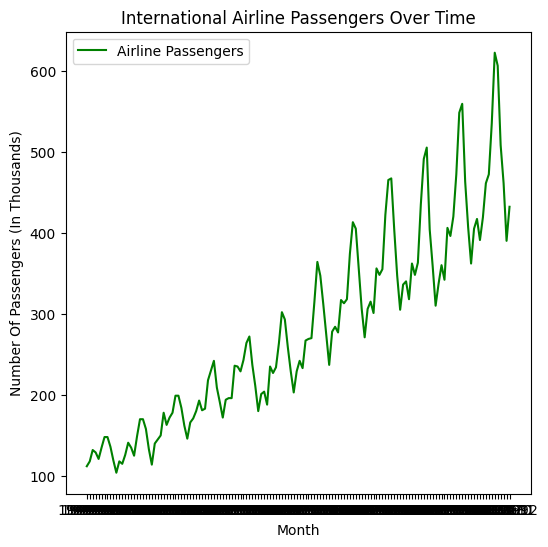

In [41]:
plt.figure(figsize=(6, 6))
plt.plot(df['Month'], df['Passengers'], label='Airline Passengers', color='green')
plt.xlabel('Month')
plt.ylabel('Number Of Passengers (In Thousands)')
plt.title('International Airline Passengers Over Time')
plt.legend()
plt.show()

# **Data Cleaning**

**This code converts the "Month" column to datetime, extracts the year and month into new columns, removes the original "Month," and renames the month number column, then displays the first five rows of the modified DataFrame.**

In [42]:
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")

df["Year"] = df["Month"].dt.year

df["Month_Date"] = df["Month"].dt.month

df.drop(columns=["Month"], inplace=True)

df.rename(columns = {"Month_Date" : "Month"}, inplace = True)

df.head(5)

,Passengers,Year,Month
0,112.0,1949,1
1,118.0,1949,2
2,132.0,1949,3
3,129.0,1949,4
4,121.0,1949,5


# **Model Building**

**This code defines the feature set X with "Year" and "Month" and the target variable y with "Passengers" from the DataFrame df.**

In [43]:
X = df[["Year", "Month"]]

y = df[["Passengers"]]

**This code normalizes the feature set X and target variable y using Min-Max scaling, transforming them into Pandas DataFrames.**

In [44]:
from sklearn.preprocessing import MinMaxScaler

Scaler_X = MinMaxScaler().set_output(transform = "pandas")

X = Scaler_X.fit_transform(X)

Scaler_y = MinMaxScaler().set_output(transform = "pandas")

y = Scaler_y.fit_transform(y)

**This code imports the train_test_split function for dataset splitting and the mean_squared_error function for evaluating model performance in regression tasks.**

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

**This code splits the feature set X and target variable y into training and testing sets, allocating 80% of the data for training and 20% for testing.**

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.80)

**This code adds a new dimension to the X_train array at the second-to-last axis, adjusting its shape for compatibility with certain models.**

In [47]:
X_train = np.expand_dims(X_train, axis=-2)

# **Deep Learning**

## **LSTM - Long Short Term Memory**

**This code imports the Sequential model class and Dense and LSTM layer classes from TensorFlow's Keras API for building neural networks.**

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

**This code snippet builds a sequential neural network model using LSTM and Dense layers and then displays a summary of the model.**

**This code creates an LSTM-based sequential model with specific layer configurations and displays its summary.**

In [49]:
model_lstm = Sequential()
model_lstm.add(LSTM(4, activation="relu", input_shape=(1, 2)))
model_lstm.add(Dense(16, activation="relu"))
model_lstm.add(Dense(8, activation="relu"))
model_lstm.add(Dense(1, activation="linear"))

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 4)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

**This code compiles the model using mean squared error as the loss function and the Adam optimizer.**

In [50]:
model_lstm.compile(loss = "mean_squared_error", optimizer="adam")

**This code fits the model to the training data for 50 epochs with a batch size of 32.**

In [51]:
model_lstm.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1756
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1675
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1571
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1405
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1252
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1306
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0983
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0880
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0676
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0694
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0585
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0495
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0495
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0508
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0503
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━━━━

**This code reshapes the test data, predicts passenger counts using the model, calculates the mean squared error, and prints the result.**

In [52]:
X_test = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

y_pred = model_lstm.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("LSTM Mean Sqaured Error: ", MSE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
LSTM Mean Sqaured Error:  0.006927179172635078


## **RNN - Recurrent Neural Network**

**This code imports the Sequential model class and the Dense and SimpleRNN layers from TensorFlow's Keras API for building neural networks.**

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

**This code creates a Simple RNN-based sequential model with specified layer configurations and displays its summary.**

In [54]:
model_rnn = Sequential()

model_rnn.add(SimpleRNN(10, activation="relu", input_shape=(1, 2)))
model_rnn.add(Dense(16, activation="relu"))
model_rnn.add(Dense(8, activation="relu"))
model_rnn.add(Dense(1, activation="linear"))

model_rnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 451 (1.76 KB)

 Trainable params: 451 (1.76 KB)

 Non-trainable params: 0 (0.00 B)

**This code compiles the model using mean squared error as the loss function and the Adam optimizer.**

In [55]:
model_rnn.compile(loss = "mean_squared_error", optimizer="adam")

**This code fits the model to the training data for 50 epochs with a batch size of 32.**

In [56]:
model_rnn.fit(X_train, y_train, epochs = 50, batch_size = 32)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1460
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1251
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0972
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0903
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0868
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0583
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0611
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0547
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0494
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0460 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0511
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0441
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0465
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0381
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0431
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━━━

**This code prints the shape of the X_test array.**

In [57]:
print("Original X_test shape:", X_test.shape)

Original X_test shape: (29, 1, 2)


**This code checks the shape of y_test, reshapes it if needed, predicts values using the model, calculates the mean squared error, and prints the result.**

In [58]:
print("Original y_test shape:", y_test.shape)

if len(y_test.shape) == 1:
    y_test = y_test.reshape((y_test.shape[0], 1))

y_pred = model_rnn.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("RNN Mean Squared Error: ", MSE)

Original y_test shape: (29, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
RNN Mean Squared Error:  0.00646954495459795


# **Conclusion:**

**RNN Mean Squared Error:  0.006469**

**LSTM Mean Sqaured Error:  0.006927**

**Based on the results, the RNN model achieved a mean squared error (MSE) of 0.006469, while the LSTM model had a higher MSE of 0.006927. This indicates that the RNN model performed better in terms of prediction accuracy, as it has the lowest mean squared error. Therefore, we conclude that the RNN is the preferred model for this task.**

# **Save The Model**

**Saves the trained model: Serializes and stores the final Recurrent Neural Network model so it can be reused without retraining.**

**Persists input scaling logic: Saves the feature scaler to ensure future data is transformed consistently.**

**Preserves output scaling logic: Stores the target scaler so predictions can be correctly inverse-transformed.**

In [59]:
import pickle

with open("Finalized-Model.pickle", "wb") as file:
    pickle.dump(model_rnn, file)

with open("Scaler_X.pickle", "wb") as file:
    pickle.dump(Scaler_X, file)

with open("Scaler_y.pickle", "wb") as file:
    pickle.dump(Scaler_y, file)